In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

### Function 2: Optimising Noisy Models

This corresponds to trying to optimise an unknown machine learning model. However, the initialization of the model is very important, meaning your observations will be very noisy, and the problem might have a lot of local optima! You are trying to make the model’s log-likelihood as large as possible.

**Problem: Optimising Noisy Models**

**What does this mean?**

**Unknown Model:**
We are trying to optimize (find the best input for) a function that we cannot see or write down explicitly. This is common in machine learning when you want to tune hyperparameters or inputs to maximize some performance metric.

**Noisy Observations:**
Every time you try an input, the output (observation) you get is noisy—it has random error. This could be due to randomness in the model, data, or measurement process.

**Many Local Optima:**
The function you are optimizing is not smooth and simple; it has many peaks and valleys (local optima). This means it’s easy to get stuck in a “good” but not “best” solution.

**Log-Likelihood Maximization:**
In machine learning, the log-likelihood is a measure of how well your model explains the data. Maximizing it means you want to find the input (or hyperparameters) that make your model fit the data as well as possible.

**Real-World Analogy**
Imagine you are tuning the settings of a complicated machine (like a car engine) to get the best performance.

Every time you change the settings and measure the output, the result is a bit random (noisy).
Sometimes, a setting gives you a good result, but there might be an even better setting elsewhere.
Your goal is to find the settings that give you the best average performance, not just a lucky high reading.

### Data Loading and Preprocessing

The following code cell loads the initial input and output data for the contamination source search problem. It also appends additional queries and observations from external files i.e. queries.txt and observations.txt, ensuring that the dataset is comprehensive and ready for further analysis and modeling.

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.66579958, 0.12396913],
        [0.87779099, 0.7786275 ],
        [0.14269907, 0.34900513],
        [0.84527543, 0.71112027],
        [0.45464714, 0.29045518],
        [0.57771284, 0.77197318],
        [0.43816606, 0.68501826],
        [0.34174959, 0.02869772],
        [0.33864816, 0.21386725],
        [0.70263656, 0.9265642 ]]),
 10)

In [4]:
#new_query_1 =  np.array([1.00000e-06, 9.99999e-01])
#new_query_2 =  np.array([0.999999, 0.999999])
#new_query_3 =  np.array([1.e-06, 1.e-06])
#new_query_4 =  np.array([9.99999e-01, 1.00000e-06])
#new_query_5 =  np.array([6.76767e-01, 1.00000e-06])
#X = np.vstack([X, new_query_1, new_query_2, new_query_3, new_query_4, new_query_5])
#X

queries = queries_for_function(2)
X = np.vstack([X, queries])
X, len(X)

(array([[6.65799580e-01, 1.23969128e-01],
        [8.77790989e-01, 7.78627501e-01],
        [1.42699074e-01, 3.49005131e-01],
        [8.45275429e-01, 7.11120267e-01],
        [4.54647141e-01, 2.90455180e-01],
        [5.77712844e-01, 7.71973184e-01],
        [4.38166062e-01, 6.85018257e-01],
        [3.41749593e-01, 2.86977198e-02],
        [3.38648157e-01, 2.13867246e-01],
        [7.02636557e-01, 9.26564198e-01],
        [5.65656000e-01, 9.99999000e-01],
        [6.66666000e-01, 2.82829000e-01],
        [8.18181000e-01, 1.91920000e-01],
        [5.55555000e-01, 1.00000000e-06],
        [5.75757000e-01, 4.64647000e-01],
        [1.72728000e-01, 6.25087000e-01],
        [3.53170000e-02, 1.43501000e-01],
        [8.66822000e-01, 4.67368000e-01],
        [1.19428000e-01, 9.50321000e-01],
        [2.63265000e-01, 6.51415000e-01],
        [9.99999000e-01, 5.25252000e-01],
        [9.99999000e-01, 5.25252000e-01],
        [8.48484000e-01, 9.79797000e-01],
        [8.48990000e-01, 4.0000000

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
         0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522]),
 10)

In [6]:
#y = np.append(y, [0.0, 1.517648729565899e-192, 2.31546114628124e-248, 0.0, 5.4713831123687026e-170], axis=0)
#y

observations = observations_for_function(2)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
         0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522,
         0.00383348,  0.45575856,  0.16684519, -0.01344612,  0.1062046 ,
         0.0482295 , -0.02461208,  0.74906492, -0.00791856, -0.06233066,
        -0.02172702,  0.01192909,  0.06253043,  0.36763342,  0.34985542,
         0.14226258,  0.7590893 ]),
 27)

In [7]:
best_idx = np.argmax(y)
print("Best input so far:", X[best_idx])
print("Best log-likelihood so far:", y[best_idx])

Best input so far: [0.866317 0.466863]
Best log-likelihood so far: 0.7590892996235141


### Identifying the Best Observation

This section locates the input point that yields the highest observed log-likelihood value so far. By finding the index of the maximum value in the `y` array, it retrieves both the best input (`X[best_idx]`) and its corresponding log-likelihood (`y[best_idx]`). This information is useful for tracking optimization progress and guiding further exploration or exploitation steps.

In [8]:
def best_observation(y):
    best_idx = np.argmax(y)  # Find the index where y is closest to zero
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7590892996235141
Best query so far: [0.866317 0.466863]


### Visualizing Input and Output Data

This section provides visualizations of the input data points (`X`) and their corresponding noisy log-likelihood observations (`y`). The scatter plots help to understand the distribution of sampled points in the input space and how the observed outputs vary, which is useful for diagnosing the optimization process and identifying regions of interest for further exploration or exploitation.

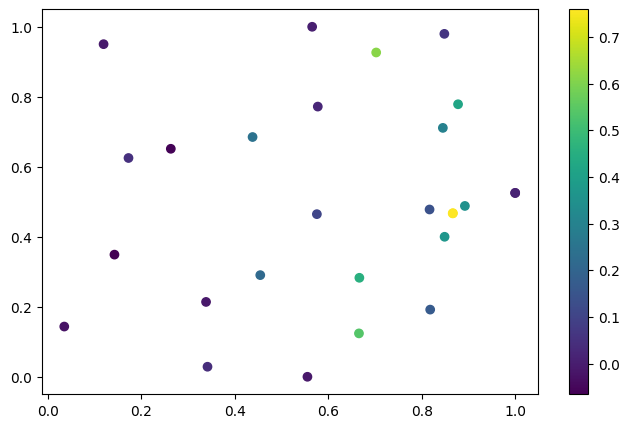

In [9]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

### 3D Visualization of Input and Output Data

The following code cell creates a 3D scatter plot of the input data points (`X`) and their corresponding noisy log-likelihood observations (`y`). This visualization helps to understand the relationship between the two input variables and the observed output, providing insights into the structure of the optimization landscape and highlighting regions with higher or lower log-likelihood values. The color of each point represents the value of `y`, making it easier to identify trends and potential areas of interest for further exploration.

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

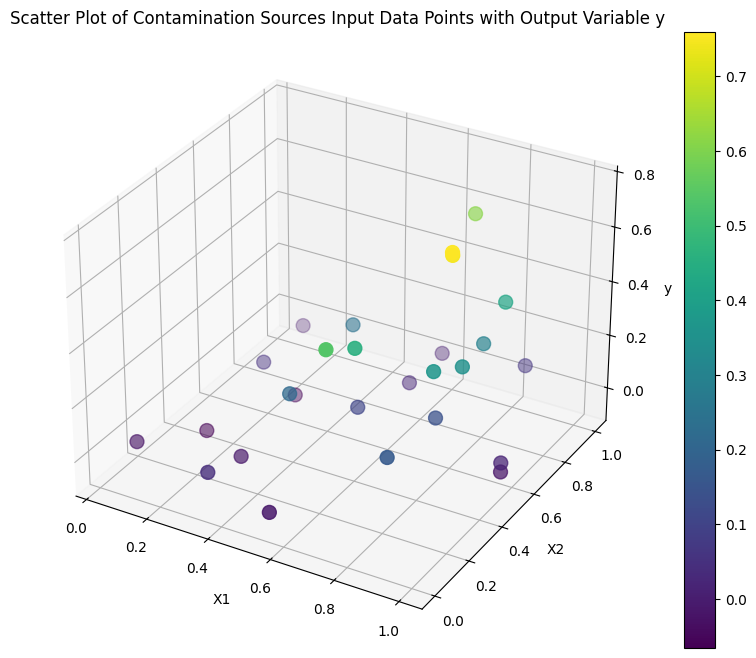

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


### Acquisition Function Implementations

The following code cell defines several popular acquisition functions used in Bayesian optimization to guide the search for optimal inputs. These functions balance exploration (sampling where the model is uncertain) and exploitation (sampling where the model predicts high values):

- **Upper Confidence Bound (UCB):** Encourages exploration by adding a multiple of the standard deviation to the mean prediction.
- **Probability of Improvement (PI):** Focuses on the probability that a new sample will improve over the current best observation.
- **Probability of Improvement with Exploration Term:** Adds an exploration parameter to PI for more balanced search.
- **Expected Improvement (EI):** Considers both the probability and magnitude of improvement over the current best.
- **Thompson Sampling:** Randomly samples from the model's posterior to select the next query point.

These acquisition functions are essential for efficiently optimizing noisy, black-box functions with many local optima.

In [11]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

### Grid Sampling Methods

The following code cell defines several strategies for generating candidate input points for Bayesian optimization. These methods help balance exploration of the entire input space and exploitation around promising regions:

- **Exploration Grid:** Generates a dense, regular grid covering the whole input space, useful for systematic exploration.
- **Exploitation Grid:** Creates a fine grid centered around a specific point (typically the current best), focusing on local search.
- **Exploration Latin Hypercube:** Uses Latin Hypercube Sampling to efficiently cover the input space with a large number of diverse points, promoting exploration.
- **Exploitation Latin Hypercube:** Applies Latin Hypercube Sampling within a small region around a given center, enabling focused exploitation.

These sampling methods are essential for efficiently searching high-dimensional spaces and improving the performance of Bayesian optimization algorithms.

In [12]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 100)
    x2_grid = np.linspace(0.000001, 0.999999, 100)

    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 100)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 100)

    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999)   # x2

    ]
    sampler = qmc.LatinHypercube(d=2)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta))   # x2
    ]
    sampler = qmc.LatinHypercube(d=2)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

### Querying the Black-Box Function with Default Kernel

The following code cell defines a function to query the black-box contamination source function using a Gaussian Process with the default RBF kernel. It supports various acquisition functions (UCB, PI, EI, Thompson Sampling, etc.) to select the next input point for evaluation. This function fits the GP model to the current data, computes the acquisition function over a candidate grid, and returns the input that maximizes the acquisition value along with its predicted output. This approach enables both exploration and exploitation.

In [13]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
    
    
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    x = x.reshape(1,2)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", model.kernel_, "Score: ", model.score(X, y))
    
    return x, y_pred

### Querying with Multiple Acquisition Functions

The following code cell defines a function that queries the black-box contamination source function using several acquisition strategies (UCB, PI, PI with exploration, EI, and Thompson Sampling) with the default RBF kernel. For each acquisition function, it fits a Gaussian Process model to the current data and selects the next input point that maximizes the respective acquisition value. This approach allows for a direct comparison of different acquisition strategies in both exploration and exploitation phases.

In [14]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

### Exploration Using the Default RBF Kernel

The following code cell performs exploration across the entire 2D input space using the default RBF kernel and multiple acquisition functions. It demonstrates how different acquisition strategies (UCB, PI, PI with exploration, EI, and Thompson Sampling) can be used to select the next promising query point for the black-box contamination source function. This approach helps in efficiently searching for both contamination sources by leveraging the strengths of each acquisition method.

In [15]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.648984-0.736523


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is 12.032065868377686
Index of maximum acquisition function value:  9900
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.8736507237185883


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is 3.153639316558838
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.8736507237185883


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is 3.153639316558838
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.8736507237185883


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is 12.0320658

### Exploitation Using the Default RBF Kernel

The following code cells demonstrates exploitation by focusing the search around the most significant query point identified from the data. Using the default RBF kernel and multiple acquisition functions, the model selects the next promising input within a local region centered at this point.

In [16]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7590892996235141
Best query so far: [0.866317 0.466863]


In [17]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.923322-0.744657


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.916317-0.516863)
Predicted Value at (0.916317-0.516863) is 0.6505019664764404
Index of maximum acquisition function value:  9999
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.8736507237185883


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816317-0.416863)
Predicted Value at (0.816317-0.416863) is 0.4195902347564697
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.8736507237185883


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816317-0.416863)
Predicted Value at (0.816317-0.416863) is 0.4195902347564697
Index of maximum acquisition function value:  0
Kernel used:  1**2 * RBF(length_scale=1) Score:  0.8736507237185883


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816317-0.416863)
Predicted Value at (0.816317-0.416863) is 0.419590

### Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters with gp_minimize
### Hyperparameter Tuning with `gp_minimize` (scikit-optimize)

The following code cell demonstrates how to use Bayesian optimization via `gp_minimize` from the `scikit-optimize` library to automatically tune the hyperparameters of the Gaussian Process model and acquisition function. The search space includes kernel type, lengthscale, noise assumption, optimizer restarts, beta (for UCB), and acquisition function choice. The best hyperparameters found are then used to query the black-box function, enabling more efficient and effective exploration of the search space.

In [18]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct

def query_black_box_function_with_kernel_choice(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-3, 1e3))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-3, 1e3))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-3, 1e3))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)


    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    x = x.reshape(1, 2)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}")
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel used: ", kernel_type, "Score: ", model.score(X, y))

    return x, y_pred

In [19]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(), 
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.909090-0.424243)
Predicted Value at (0.909090-0.424243) is 0.28887806577744235
Index of maximum acquisition function value:  4290
Kernel used:  RBF Score:  0.9400086983341936


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.989898-0.111112)
Predicted Value at (0.989898-0.111112) is 0.22787536815331738
Index of maximum acquisition function value:  1198
Kernel used:  RationalQuadratic Score:  0.36334896791991445


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.444445)
Predicted Value at (0.868686-0.444445) is 0.7496055933787051
Index of maximum acquisition function value:  4486
Kernel used:  RBF Score:  0.9996398289273312


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949494-0.414142)
Predicted Value at (0.949494-0.414142) is 0.29662581940462224
Index of maximum acquisition function value:  4194
Kernel used:  RBF Score:  0.3175607528174891


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.3969704263214471
Index of maximum acquisition function value:  99
Kernel used:  DotProduct Score:  0.24996051969390576


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.3301006064991707
Index of maximum acquisition function val

...



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.39874719175543216
Index of maximum acquisition function value:  99
Kernel used:  DotProduct Score:  0.25014997843871944
Best Parameters: rbf_lengthscale=0.9214216775197215, noise_assumption=1e-10, restarts=15, beta=1.1365367271814912, acquisition_func=expected_improvement, kernel_type=RBF


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.000001)
Predicted Value at (0.868686-0.000001) is 34.208600510290125
Index of maximum acquisition function value:  86
Kernel used:  RBF Score:  0.9996532889106956


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[8.68686131e-01, 1.00000000e-06]]), array([34.20860051]))

### Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with gp_minimize

In [20]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploration_grid(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.959595-0.000001)
Predicted Value at (0.959595-0.000001) is 2.497944715406362
Index of maximum acquisition function value:  95
Kernel used:  RBF Score:  0.9996532916276175


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


(array([[9.5959504e-01, 1.0000000e-06]]), array([2.49794472]))

### Exploitation: Exploit around the best observations

In [21]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7590892996235141
Best query so far: [0.866317 0.466863]


In [22]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploitation_grid(best_query_so_far), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.816317-0.416863)
Predicted Value at (0.816317-0.416863) is 1.7875642746221274
Index of maximum acquisition function value:  0
Kernel used:  RBF Score:  0.9996532913755881


(array([[0.816317, 0.416863]]), array([1.78756427]))

### Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters using from bayes_opt import BayesianOptimization
### Hyperparameter Tuning with `BayesianOptimization` (bayes_opt)

The following code cell demonstrates how to use the `BayesianOptimization` package from `bayes_opt` to automatically tune the hyperparameters of the Gaussian Process model and acquisition function. The optimizer explores the search space for kernel type, lengthscale, noise assumption, optimizer restarts, beta (for UCB), and acquisition function choice. The best hyperparameters found are then used to query the black-box function, enabling more efficient and effective exploration of search space.

In [23]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_kernel_choice(
        X, y, exploration_grid(),
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_kernel_choice(
    X, y, exploration_grid(),
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.605896285304322
Index of maximum acquisition function value:  4686
Kernel used:  RationalQuadratic Score:  0.9457065005462619
| 1         | -0.6059   | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.858585-0.464647)
Predicted Value at (0.858585-0.464647) is 0.5706597263441033
Index of maximum acquisition function value:  4685
Kernel used:  RationalQuadratic Score:  0.9985554007803045
| 2         | -0.5707   | 0.2323    | 2.732     | 1.803     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.33796319392254226
Index of maximum acquisition function value:  99
Kernel used:  Matern Score:  0.27927795757105356
| 3         | -0.338    | 3.33      | 1.425     | 0.5455    | 0.1916    | 0.03042   | 7.871     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.1711535453846055
Index of maximum acquisition function value:  99
Kernel used:  RationalQuadratic Score:  0.8343553576970506
| 4       

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.4344435635150603
Index of maximum acquisition function value:  4686
Kernel used:  RationalQuadratic Score:  0.9996532834719556
| 7         | -0.4344   | 2.825     | 1.0       | 2.281     | 0.01      | 1e-10     | 5.983     |


...



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.20601950809729488
Index of maximum acquisition function value:  99
Kernel used:  RationalQuadratic Score:  0.31160672716306015
| 39        | -0.206    | 3.319     | 1.128     | 1.837     | 0.2774    | 0.05606   | 5.836     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.7173225591058381
Index of maximum acquisition function value:  4686
Kernel used:  RationalQuadratic Score:  0.9995506411918325
| 40        | -0.7173   | 0.7271    | 1.071     | 1.823     | 0.4416    | 0.0005691 | 4.138     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.6100101219793126
Index of maximum acquisition function value:  4686
Kernel used:  RationalQuadratic Score:  0.9509860493687055
| 41        | -0.61  

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.2044392794619957
Index of maximum acquisition function value:  99
Kernel used:  RBF Score:  0.26541971123596675
| 51        | -0.2044   | 0.6526    | 2.662     | 0.1888    | 0.4807    | 0.09014   | 9.76      |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.868686-0.464647)
Predicted Value at (0.868686-0.464647) is 0.547538565638584
Index of maximum acquisition function value:  4686
Kernel used:  RationalQuadratic Score:  0.8486513694774676
| 52        | -0.5475   | 2.786     | 2.398     | 1.882     | 0.2265    | 0.02772   | 0.2039    |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.000001)
Predicted Value at (0.999999-0.000001) is 0.20664792370666837
Index of maximum acquisition function value:  99
Kernel used:  RBF Score:  0.2810427828442449
| 53        | -0.2066   | 1.36      | 1.538     | 0.

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optim

(array([[9.99999e-01, 1.00000e-06]]), array([-0.12492802]))

### Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with BaysianOptimization

In [24]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploration_latin_hypercube(), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.997489-0.006544)
Predicted Value at (0.997489-0.006544) is -0.11975285557962367
Index of maximum acquisition function value:  6583
Kernel used:  Matern Score:  0.7671031867172537


(array([[0.99748889, 0.00654419]]), array([-0.11975286]))

### Exploitation: Exploit around the best observations

In [25]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 0.7590892996235141
Best query so far: [0.866317 0.466863]


In [26]:
next_query, y_pred = query_black_box_function_with_kernel_choice(X, y, exploitation_latin_hypercube(best_query_so_far), 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.915989-0.416934)
Predicted Value at (0.915989-0.416934) is 0.38683326326880874
Index of maximum acquisition function value:  486
Kernel used:  Matern Score:  0.7671031856499448


(array([[0.91598933, 0.41693373]]), array([0.38683326]))